In [204]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [207]:
df= pd.read_csv("zomato_dataset_Engineered.csv")

In [235]:
df.describe()

,delivery_person_age,delivery_person_ratings,distance_km,time_ordered,time_order_picked,vehicle_condition,multiple_deliveries,time_taken_min,is_weekend,rating_category
count,45493.000000,45493.000000,45493.000000,43853.000000,45493.000000,45493.000000,44500.000000,45493.000000,45493.000000,45493.000000
mean,29.554779,4.637995,9.737738,16.287218,16.029691,1.019432,0.744899,26.296947,0.274833,4.745719
std,5.642756,0.307473,5.606385,6.638570,6.936229,0.835219,0.572525,9.386912,0.446435,0.448541
min,20.000000,2.500000,1.500000,0.220000,0.050000,0.000000,0.000000,10.000000,0.000000,2.000000
25%,25.000000,4.600000,4.700000,11.500000,11.400000,0.000000,0.000000,19.000000,0.000000,5.000000
50%,29.554779,4.700000,9.200000,18.450000,18.450000,1.000000,1.000000,26.000000,0.000000,5.000000
75%,34.000000,4.800000,13.700000,21.250000,21.250000,2.000000,1.000000,32.000000,1.000000,5.000000
max,39.000000,5.000000,21.000000,23.550000,23.550000,3.000000,3.000000,54.000000,1.000000,5.000000


## UNIVARIATE AND BIVARIATE ANALYSIS

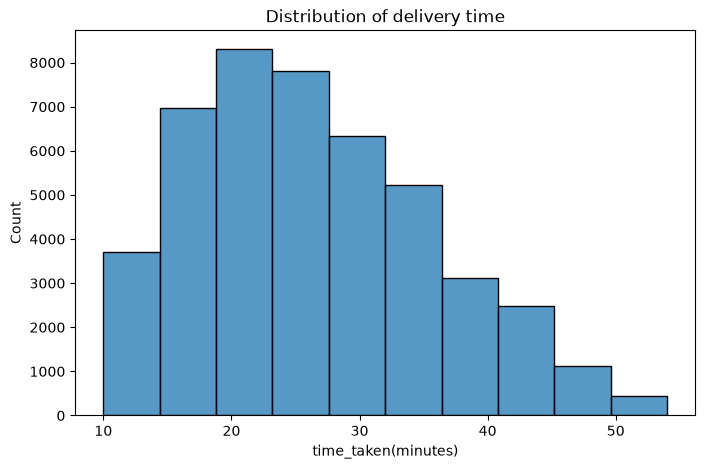

In [212]:
plt.figure (figsize=(8,5))
sns.histplot(df["time_taken_min"],bins = 10)
plt.title("Distribution of delivery time")
plt.xlabel("time_taken(minutes)")
plt.ylabel("Count")
plt.show()

**INSIGHT : Right skewed.Most deliveries are completed quickly and few orders take significantly longers time and average delivery time is 26.2 min**

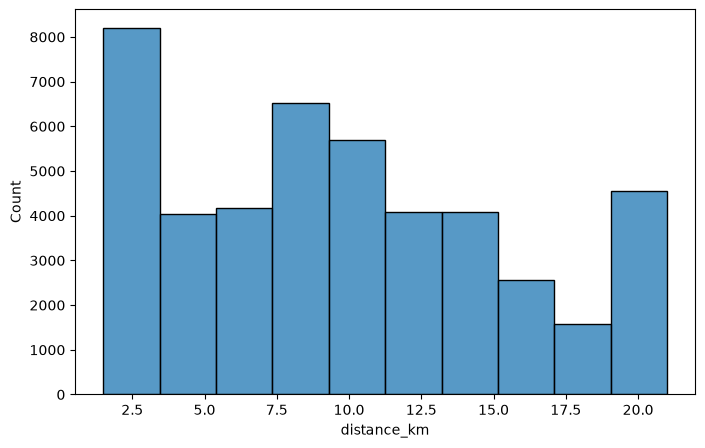

In [213]:
plt.figure (figsize=(8,5))
sns.histplot(data=df , x = "distance_km",bins = 10)
plt
plt.show()

**INSIGHT : Most delivveries are very short (under 2.5km) and the range is 0 to 22km roughly**

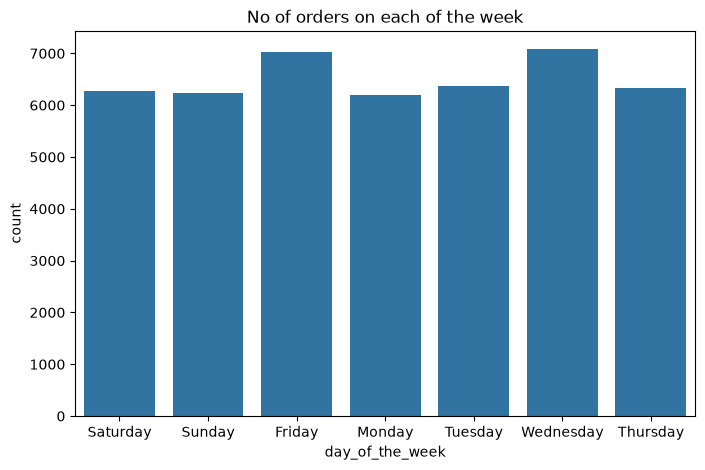

In [214]:
plt.figure (figsize=(8,5))
plt.title("No of orders on each of the week")
sns.countplot(data=df , x = "day_of_the_week")
plt.show()

**INSIGHT : Fridays and wednesday experiences highest delivery volumes**

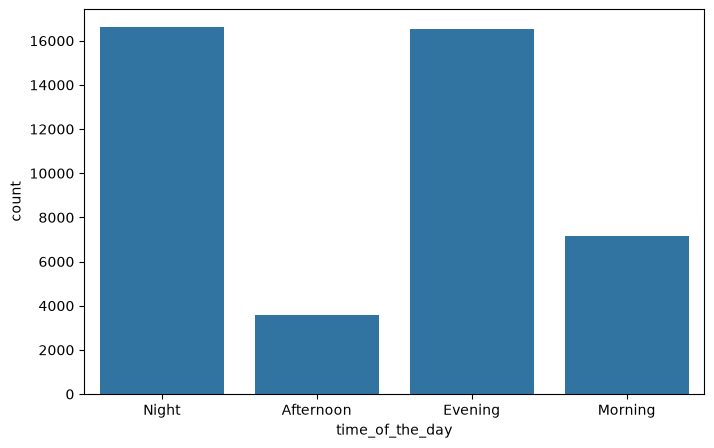

In [215]:
plt.figure (figsize=(8,5))
sns.countplot(data=df, x="time_of_the_day")
plt.show()

**INSIGHT : We can clearly see the delivery is peaking from 5 pm till midnight**

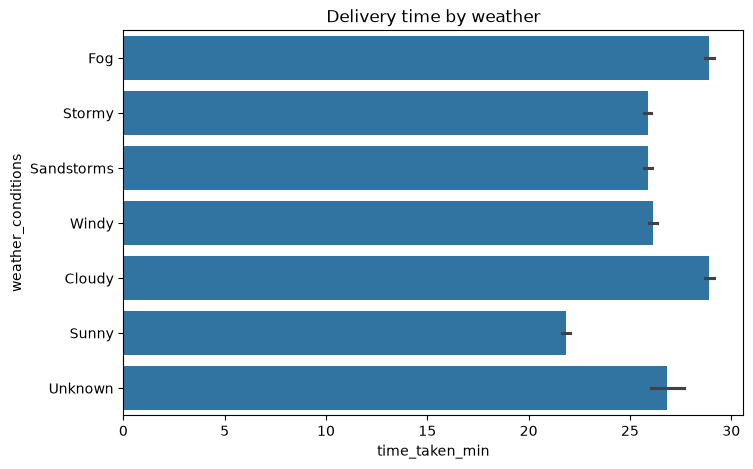

In [216]:
plt.figure (figsize=(8,5))
sns.barplot(data = df,x= "time_taken_min", y ="weather_conditions")
plt.title("Delivery time by weather")
plt.show()

**INSIGHT : The delivery during normal sunny condition is relatively faster**

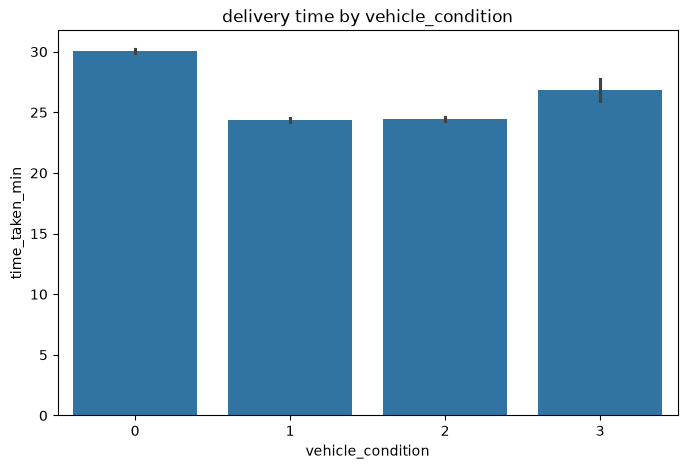

In [217]:
plt.figure (figsize=(8,5))
sns.barplot(data = df,x= "vehicle_condition",y= "time_taken_min")
plt.title("delivery time by vehicle_condition")
plt.show()

In [218]:
df['vehicle_condition'].value_counts(normalize=True,dropna =False)*100

vehicle_condition
2    33.040248
1    33.033654
0    32.983096
3     0.943002
Name: proportion, dtype: float64

**INSIGHT : Delivery time remains relatively constant between vehicle conditions 1 and 2.However poor vehicle show a noticable increase in delivery time, vehicle condition consist only 0.9% of data and more variation so we can interpret it takes more time.**

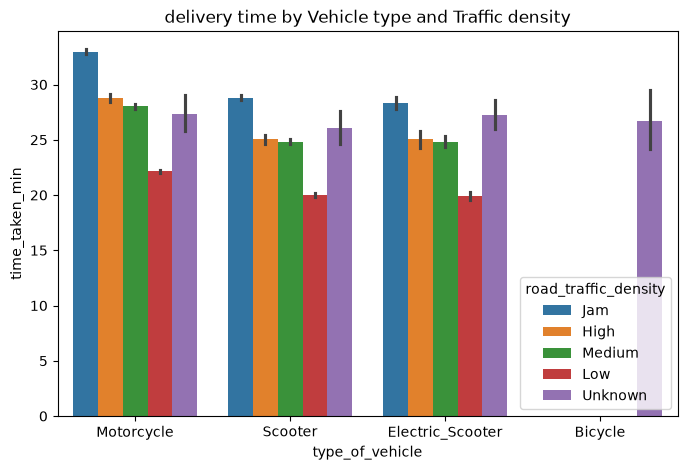

In [219]:
plt.figure (figsize=(8,5))
sns.barplot(data = df,x= "type_of_vehicle",y= "time_taken_min",hue =  "road_traffic_density")
plt.title("delivery time by Vehicle type and Traffic density")
plt.show()

In [220]:
df['type_of_vehicle'].value_counts(normalize=True,dropna =False)*100

type_of_vehicle
Motorcycle          58.077067
Scooter             33.501857
Electric_Scooter     8.304574
Bicycle              0.116501
Name: proportion, dtype: float64

**INSIGHT : In heavy jams condition , scooters and electric scooters show slight edge over motorcycle**

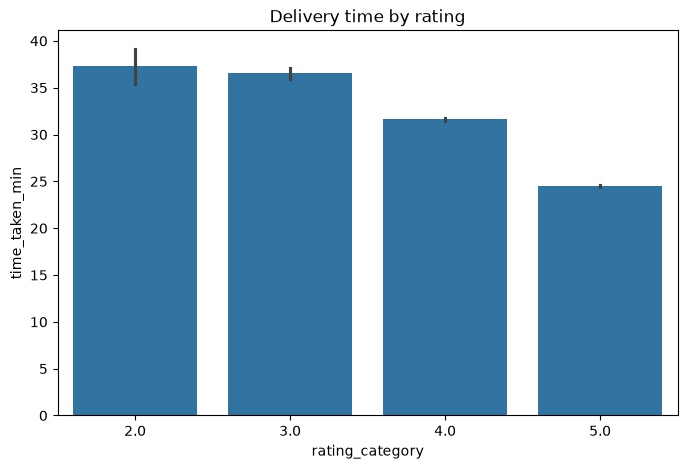

In [221]:
plt.figure (figsize=(8,5))
sns.barplot(data=df ,x= "rating_category",y="time_taken_min")
plt.title("Delivery time by rating")
plt.show()

**INSIGHT : Those who delivered fast eventualy has higher rating**

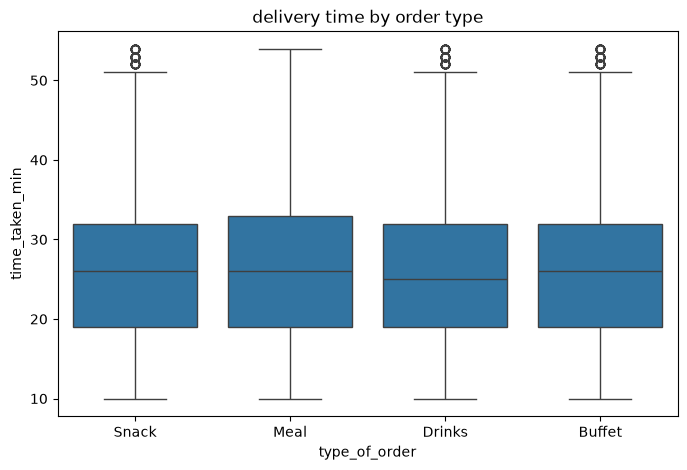

In [222]:
plt.figure (figsize=(8,5))
sns.boxplot(data = df,x= "type_of_order",y= "time_taken_min")

plt.title("delivery time by order type")
plt.show()

**INSIGHT : type_of_orders have uniform distribution , but there is a presence of outliers which goes above 50 min for delivery except meal**

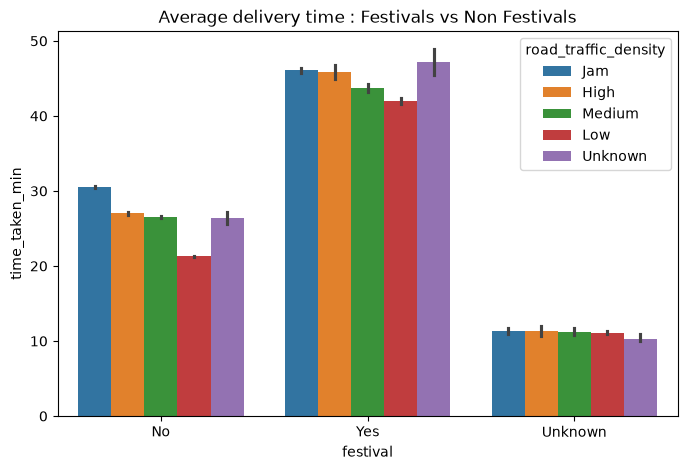

In [223]:
plt.figure (figsize=(8,5))
sns.barplot(data=df ,x= "festival",y="time_taken_min",hue = "road_traffic_density")
plt.title("Average delivery time : Festivals vs Non Festivals")
plt.show()

**This visual shows that the time for delivery has increased during festival_season**

In [224]:
df["type_of_order"].value_counts()

type_of_order
Snack     11509
Meal      11433
Drinks    11293
Buffet    11258
Name: count, dtype: int64

In [225]:
df_corr = df[['delivery_person_age', 'delivery_person_ratings',
       'vehicle_condition', 'multiple_deliveries', 'time_taken_min','distance_km']].corr()

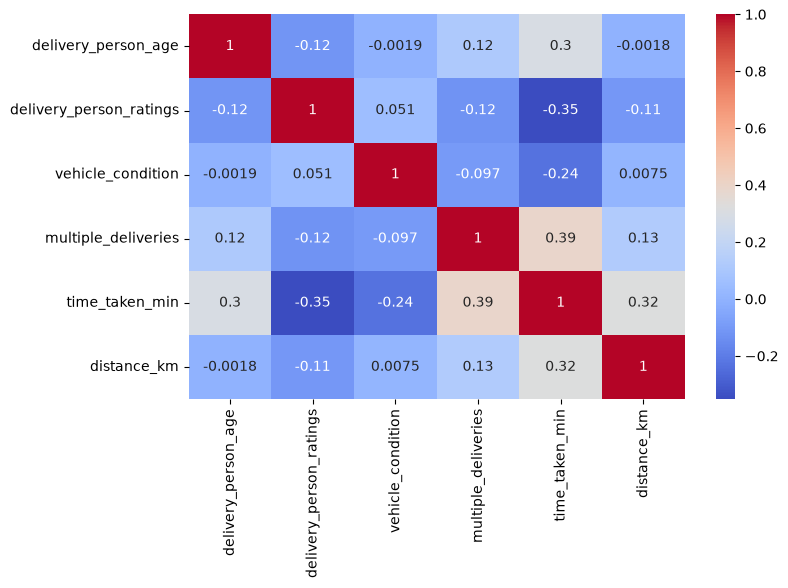

In [226]:
plt.figure (figsize=(8,5))
sns.heatmap(df_corr,annot = True,cmap ="coolwarm")
plt.show()

In [227]:
mean_distribution = df["time_taken_min"].mean()
print("Average time for delivery is",round(mean_distribution,2),"min")

Average time for delivery is 26.3 min


In [228]:
mean_age = df["delivery_person_age"].mean()
print("The average of a delivery person is",round(mean_age))

The average of a delivery person is 30


In [229]:
Fastest_delivery =df["time_taken_min"].min()
print("The fastest delivery time is",Fastest_delivery,"min")

The fastest delivery time is 10 min


**Finding outliers**

In [230]:
Q1 =  df["time_taken_min"].quantile(0.25)
Q3 =  df["time_taken_min"].quantile(0.75)
IQR = Q3 - Q1

In [231]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [232]:
outliers_df = df[(df["time_taken_min"]<lower_bound) | (df["time_taken_min"]>upper_bound)]

In [233]:
outliers_df.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,distance_km,order_date,time_ordered,time_order_picked,weather_conditions,road_traffic_density,...,type_of_vehicle,multiple_deliveries,festival,city,time_taken_min,day_of_the_week,is_weekend,rating_category,time_of_the_day,distance_bucket
34,0xb796,SURRES17DEL03,37.0,4.7,13.7,2022-04-04,19.45,19.50,Sandstorms,Jam,...,Motorcycle,3.0,No,Metropolitian,52,Monday,0,5.0,Evening,Long
179,0x4b5b,MYSRES04DEL03,38.0,4.3,14.0,2022-04-04,21.15,21.25,Sandstorms,Jam,...,Motorcycle,1.0,Yes,Semi-Urban,54,Monday,0,4.0,Night,Long
257,0xd92f,AGRRES03DEL01,35.0,4.9,10.4,2022-02-18,21.15,21.30,Cloudy,Jam,...,Motorcycle,2.0,No,Metropolitian,53,Friday,0,5.0,Night,Long
632,0xc2ba,LUDHRES18DEL03,20.0,3.9,8.8,2022-02-11,20.40,20.45,Sunny,Jam,...,Motorcycle,1.0,No,Metropolitian,54,Friday,0,4.0,Evening,Medium
713,0x836d,HYDRES06DEL01,31.0,4.4,10.8,2022-03-25,19.35,19.40,Stormy,Jam,...,Motorcycle,1.0,Yes,Metropolitian,53,Friday,0,4.0,Evening,Long


**The outliers exists in delivery time might be due to traffic jam,the time taken went above 51.5min(upper_bound)**

In [234]:
upper_bound

np.float64(51.5)

# INSIGHTS

**The average delivery time is 26.3 minutes (median 26 min, range 10–54 min). The distribution is moderately right-skewed, meaning most deliveries cluster between 19–32 minutes (IQR), with a smaller share of orders taking noticeably longer.**

**There is no meaningful difference in delivery time between weekends and weekdays — delivery speed appears to be driven more by traffic and order load than by the day itself.**

**Heavy traffic is the single largest factor slowing down order completion.**

**Foggy, stormy, and sandstorm conditions correlate with a 15–25% increase in time taken per delivery compared to clear or cloudy weather.**

**Scooter deliveries show higher efficiency during high-density traffic compared to motorcycles, likely due to easier navigation through jams.**